# 01.01 What Does an A/B Test Estimate?

A/B Test 的核心不是简单比较两个数字，而是估计一个产品改动对用户行为指标的因果影响。

在一个典型实验中：

- A 组：Control Group，对照组，看到旧版本；
- B 组：Treatment Group，实验组，看到新版本；
- Metric：实验指标，例如转化率、留存率、人均收入、平均游戏局数等；
- Effect：实验组相对于对照组的指标变化。

从业务角度看，A/B Test 回答的问题是：

> 如果我们把新版本上线给所有用户，核心指标会发生什么变化？

从统计角度看，A/B Test 估计的是处理效应，也就是 Treatment Effect。

## Potential Outcome Framework

对每个用户 \(i\)，理论上存在两个潜在结果：

$$
Y_i(1)
$$

表示用户 \(i\) 看到实验版本后的结果；

$$
Y_i(0)
$$

表示用户 \(i\) 看到对照版本后的结果。

但是现实中，每个用户只能看到一个版本，所以我们只能观察到：

$$
Y_i = T_iY_i(1) + (1 - T_i)Y_i(0)
$$

其中：

$$
T_i =
\begin{cases}
1, & \text{用户进入 Treatment Group} \\
0, & \text{用户进入 Control Group}
\end{cases}
$$

A/B Test 最关心的是平均处理效应：

$$
ATE = E[Y_i(1) - Y_i(0)]
$$

在随机分流成立时，可以用两组样本均值之差估计它：

$$
\hat{\tau} = \bar{Y}_T - \bar{Y}_C
$$

其中：

$$
\bar{Y}_T = \frac{1}{n_T}\sum_{i:T_i=1}Y_i
$$

$$
\bar{Y}_C = \frac{1}{n_C}\sum_{i:T_i=0}Y_i
$$

## 一个模拟例子

### 生成模拟数据

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# 固定随机数种子
rng = np.random.default_rng( seed=42 )

In [3]:
# 设置模拟参数
n_users = 10000
p_control = 0.10
p_treatment = 0.12

In [4]:
# 随机分流用户
group = rng.choice(a=["control", "treatment"], size=n_users, p=[0.5, 0.5])
group

array(['treatment', 'control', 'treatment', ..., 'control', 'control',
       'control'], shape=(10000,), dtype='<U9')

In [5]:
# 对随机分配用户进行转化模拟
converted = np.where(
    group == "control",
    rng.binomial(n=1, p=p_control, size=n_users),
    rng.binomial(n=1, p=p_treatment, size=n_users)
)
converted

array([0, 0, 0, ..., 0, 0, 0], shape=(10000,))

In [6]:
# 生成模拟数据
df = pd.DataFrame(data={
    "user_id": np.arange(1, n_users + 1),
    "group": group,
    "converted": converted
})
df

,user_id,group,converted
0,1,treatment,0
1,2,control,0
2,3,treatment,0
3,4,treatment,0
4,5,control,0
...,...,...,...
9995,9996,control,0
9996,9997,control,0
9997,9998,control,0
9998,9999,control,0


### 计算模拟转化

In [7]:
summary = df.groupby(by=["group"]).agg(
    users = ("user_id", "count"),
    conversions = ("converted", "sum"),
    conversion_rate = ("converted", "mean")
).reset_index()
summary

,group,users,conversions,conversion_rate
0,control,5015,514,0.102493
1,treatment,4985,593,0.118957


In [8]:
# 计算实验效果
convertion_rate = summary.loc[summary["group"] == "control", "conversion_rate"].iloc[0]
treatment_rate = summary.loc[summary["group"] == "treatment", "conversion_rate"].iloc[0]

absolute_lift = treatment_rate - convertion_rate
relative_lift = (treatment_rate - convertion_rate) / convertion_rate

convertion_rate, treatment_rate, absolute_lift, relative_lift

(np.float64(0.10249252243270189),
 np.float64(0.1189568706118355),
 np.float64(0.016464348179133614),
 np.float64(0.1606395060668387))

### 绘制分组结果

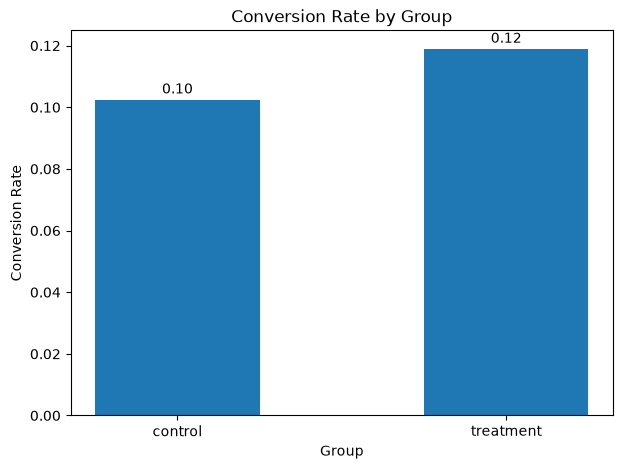

In [9]:
fig, ax = plt.subplots(figsize=(7,5))

ax.bar(x=summary["group"], height=summary["conversion_rate"], width=0.5)
ax.set_title("Conversion Rate by Group")
ax.set_xlabel("Group")
ax.set_ylabel("Conversion Rate")

for i,value in enumerate(summary["conversion_rate"]):
    ax.text(x=i, y=value + 0.002, s=f"{value:.2f}", ha="center")

plt.show()

# 01.02 Why Random Assignment Supports Causal Interpretation

A/B Test 的核心前提是随机分流。

如果用户被随机分到 Control Group 和 Treatment Group，那么实验组和对照组在实验开始前的用户特征上，理论上应该是相似的。

这些特征包括：

- 用户活跃度；
- 付费倾向；
- 游戏水平；
- 历史消费；
- 设备类型；
- 国家或地区；
- 新老用户状态；
- 对产品功能的偏好。

随机分流的目的不是让每一个用户都一样，而是让两组用户在整体分布上相似。

因此，如果实验后 Treatment 组和 Control 组的指标出现系统性差异，我们才更有理由把这个差异解释为 Treatment 造成的影响。

## Mathematical Idea

在潜在结果框架下，每个用户都有两个潜在结果：

$$
Y_i(1)
$$

表示用户 $i$ 接受 Treatment 后的结果。

$$
Y_i(0)
$$

表示用户 $i$ 接受 Control 后的结果。

随机分流意味着：

$$
T_i \perp (Y_i(1), Y_i(0))
$$

这表示用户是否进入 Treatment Group，与用户本身的潜在结果无关。

换句话说：

$$
E[Y_i(1) \mid T_i = 1] = E[Y_i(1)]
$$

$$
E[Y_i(0) \mid T_i = 0] = E[Y_i(0)]
$$

所以：

$$
E[Y_i \mid T_i = 1] - E[Y_i \mid T_i = 0]
= E[Y_i(1)] - E[Y_i(0)]
$$

也就是：

$$
E[\bar{Y}_T - \bar{Y}_C] = ATE
$$

因此，在随机分流成立时，两组样本均值之差可以作为平均处理效应的估计量。

## 一个模拟例子

In [10]:
n_users = 10_000

In [11]:
# 模拟用户类型
user_type = rng.choice(
    a=["Low Intent", "High Intent"],
    size=n_users,
    p=[0.7, 0.3]
)
user_type

array(['Low Intent', 'Low Intent', 'High Intent', ..., 'High Intent',
       'Low Intent', 'Low Intent'], shape=(10000,), dtype='<U11')

In [12]:
# 模拟不同类型的用户转化率
baseline_conversion_rate = np.where(
    user_type == "High Intent",
    0.20,
    0.05
)
baseline_conversion_rate

array([0.05, 0.05, 0.2 , ..., 0.2 , 0.05, 0.05], shape=(10000,))

In [13]:
# 生成模拟数据
users = pd.DataFrame(data={
    "user_id": np.arange(1, n_users + 1),
    "user_type": user_type,
    "baseline_conversion_prob": baseline_conversion_rate
})
users

,user_id,user_type,baseline_conversion_prob
0,1,Low Intent,0.05
1,2,Low Intent,0.05
2,3,High Intent,0.20
3,4,Low Intent,0.05
4,5,Low Intent,0.05
...,...,...,...
9995,9996,High Intent,0.20
9996,9997,High Intent,0.20
9997,9998,High Intent,0.20
9998,9999,Low Intent,0.05


### 随机分流情况

In [14]:
# 随机分流情况
random_df = users.copy()
random_df["group"] = rng.choice(
    a=["Control", "Treatment"],
    size=n_users,
    p=[0.5, 0.5]
)

# Treatment没有效果，转化率只与用户的类型有关
random_df["converted"] = rng.binomial(
    n=1,
    p=random_df["baseline_conversion_prob"]
)

random_df

,user_id,user_type,baseline_conversion_prob,group,converted
0,1,Low Intent,0.05,Control,0
1,2,Low Intent,0.05,Control,0
2,3,High Intent,0.20,Control,0
3,4,Low Intent,0.05,Control,0
4,5,Low Intent,0.05,Treatment,0
...,...,...,...,...,...
9995,9996,High Intent,0.20,Treatment,0
9996,9997,High Intent,0.20,Control,0
9997,9998,High Intent,0.20,Treatment,0
9998,9999,Low Intent,0.05,Treatment,0


In [15]:
# 在这种情况下计算两组平均转化率
random_summary = random_df.groupby(by=["group"]).agg(
    users=("user_id", "count"),
    conversions=("converted", "sum"),
    conversion_rate=("converted", "mean")
)
random_summary

,users,conversions,conversion_rate
group,,,
Control,4961,459,0.092522
Treatment,5039,496,0.098432


In [16]:
# 检查两组用户的构成
pd.crosstab(
    random_df["group"],
    random_df["user_type"],
    normalize="index"
)

user_type,High Intent,Low Intent
group,,
Control,0.300746,0.699254
Treatment,0.307204,0.692796


### 非随机分流情况

In [17]:
biased_df = users.copy()

# 非随机分流：假设高意向用户更容易进入Treatment
treatment_prob = np.where(
    biased_df["user_type"] == "High Intent",
    0.80,
    0.40
)

## 随后对用户进行分组
biased_df["group"] = np.where(
    rng.binomial(n=1, p=treatment_prob) == 1,
    "Treatment",
    "Control"
)

# Treatment没有真实效果
biased_df["converted"] = rng.binomial(
    n=1,
    p=biased_df["baseline_conversion_prob"]
)
biased_df

,user_id,user_type,baseline_conversion_prob,group,converted
0,1,Low Intent,0.05,Treatment,0
1,2,Low Intent,0.05,Treatment,0
2,3,High Intent,0.20,Control,0
3,4,Low Intent,0.05,Treatment,0
4,5,Low Intent,0.05,Control,0
...,...,...,...,...,...
9995,9996,High Intent,0.20,Treatment,0
9996,9997,High Intent,0.20,Treatment,0
9997,9998,High Intent,0.20,Treatment,0
9998,9999,Low Intent,0.05,Treatment,0


In [18]:
# 计算分组转化率
biased_summary = biased_df.groupby(by="group").agg(
    users=("user_id", "count"),
    conversions=("converted", "sum"),
    conversion_rate=("converted", "mean")
).reset_index()
biased_summary

,group,users,conversions,conversion_rate
0,Control,4795,372,0.077581
1,Treatment,5205,658,0.126417


In [19]:
# 检查用户构成
biased_balance = pd.crosstab(
    index=biased_df["group"],
    columns=biased_df["user_type"],
    normalize="index"
)
biased_balance

user_type,High Intent,Low Intent
group,,
Control,0.129093,0.870907
Treatment,0.465130,0.534870


# 01.03 Common Metrics in A/B Testing

A/B Test 的第一步不是写检验代码，而是定义实验指标。

实验指标决定了：

- 实验要优化什么；
- 实验是否成功；
- 统计检验使用什么方法；
- 样本量应该如何估计；
- 业务结论应该如何解释。

一个实验通常不会只有一个指标，而是会包含：

- Primary Metric：主指标；
- Secondary Metrics：辅助指标；
- Guardrail Metrics：护栏指标。

例如，一个游戏新手引导实验可能会这样定义：

| Metric Type | Metric | Business Meaning |
|---|---|---|
| Primary Metric | D1 Retention | 新手引导是否提升次日留存 |
| Secondary Metric | Tutorial Completion Rate | 用户是否完成新手教程 |
| Secondary Metric | Average Playtime | 用户是否玩得更久 |
| Guardrail Metric | Crash Rate | 新版本是否带来技术问题 |
| Guardrail Metric | Payment Conversion Rate | 留存提升是否牺牲付费转化 |

指标定义越清楚，实验解释越稳定。

## Common Metric Types

A/B Test 中常见指标大致可以分为四类。

### 1. Conversion Metric

转化率指标，例如：

- 点击率；
- 注册率；
- 支付转化率；
- 新手教程完成率；
- 关卡完成率。

这类指标通常是二元变量：

$$
Y_i \in \{0, 1\}
$$

转化率定义为：

$$
\hat{p} = \frac{\sum_{i=1}^{n} Y_i}{n}
$$

### 2. Retention Metric

留存率指标，例如：

- D1 Retention；
- D3 Retention；
- D7 Retention；
- 次周留存；
- 次月留存。

留存率本质上也是转化率的一种，只是事件从“是否购买”变成了“是否回来”。

例如 D1 留存：

$$
D1\ Retention = \frac{\text{Number of users active on day 1}}{\text{Number of new users on day 0}}
$$

### 3. Mean Metric

均值类指标，例如：

- 人均游戏局数；
- 人均使用时长；
- 人均收入；
- 人均点击次数；
- 人均观看视频数。

均值定义为：

$$
\bar{Y} = \frac{1}{n}\sum_{i=1}^{n}Y_i
$$

### 4. Ratio Metric

比率类指标，例如：

- ARPU；
- ARPPU；
- 客单价；
- 每次访问收入；
- 每局游戏广告收入。

这类指标经常写成：

$$
Ratio = \frac{\sum_i X_i}{\sum_i Z_i}
$$

例如 ARPU：

$$
ARPU = \frac{\text{Total Revenue}}{\text{Total Users}}
$$

ARPPU：

$$
ARPPU = \frac{\text{Total Revenue}}{\text{Paying Users}}
$$

Ratio Metric 的统计性质通常比普通均值更复杂，后面需要单独处理。

## 一个模拟例子
现在我们通过一个模拟一个数据集的形式来熟悉这些指标

In [20]:
group = rng.choice(
    a = ["Control", "Treatment"],
    size = n_users,
    p = [0.5, 0.5]
)

In [21]:
df = pd.DataFrame({
    "user_id": np.arange(1, n_users+1),
    "group": group
})

df

,user_id,group
0,1,Treatment
1,2,Control
2,3,Treatment
3,4,Treatment
4,5,Control
...,...,...
9995,9996,Control
9996,9997,Treatment
9997,9998,Treatment
9998,9999,Treatment


### 生成实验指标

In [22]:
# 生成实验指标
## 不同基准组的基准概率
tutorial_completion_prob = np.where(
    df["group"] == "Treatment",
    0.60,
    0.55
)

d1_retention_prob = np.where(
    df["group"] == "Treatment",
    0.33,
    0.30
)

crash_prob = np.where(
    df["group"] == "Treatment",
    0.035,
    0.025
)

## 二元指标
df["tutorial_completed"] = rng.binomial(
    n=1,
    p=tutorial_completion_prob
)
df["d1_retained"] = rng.binomial(
    n=1,
    p=d1_retention_prob
)

df["crashed"] = rng.binomial(
    n=1,
    p=crash_prob
)

## 均值类指标
df["playtime_minutes"] = np.where(
    df["group"],
    rng.gamma(shape=2.2, scale=8, size=n_users),    # 生成两个随机数组供选择，而不是将两个随机数广播成数组
    rng.gamma(shape=2.0, scale=8, size=n_users)
)

## 收入指标
paid = rng.binomial(n=1, p=0.06, size=n_users)

df["revenue"] = paid * rng.lognormal(
    mean = 2.0,
    sigma = 1.0,
    size = n_users
)

df

,user_id,group,tutorial_completed,d1_retained,crashed,playtime_minutes,revenue
0,1,Treatment,1,1,0,5.571289,0.0
1,2,Control,1,1,0,18.236023,0.0
2,3,Treatment,0,0,0,12.379623,0.0
3,4,Treatment,1,0,0,8.503500,0.0
4,5,Control,0,1,0,5.928517,0.0
...,...,...,...,...,...,...,...
9995,9996,Control,1,0,0,15.395343,0.0
9996,9997,Treatment,1,0,0,40.177608,0.0
9997,9998,Treatment,1,0,0,1.845966,0.0
9998,9999,Treatment,1,0,0,9.136367,0.0


### 计算每组指标

In [23]:
metric_summary = (
    df.groupby(by="group").agg(
        users=("user_id", "count"),
        tutorial_completion_rate=("tutorial_completed", "mean"),
        d1_retention_rate=("d1_retained", "mean"),
        avg_playtime_minutes=("playtime_minutes", "mean"),
        total_revenue=("revenue", "sum"),
        playing_users=("revenue", lambda x: (x>0).sum()),
        arpu=("revenue", "mean"),
        crash_rate=("crashed", "mean")
    )
).reset_index()

metric_summary["arppu"] = (
    metric_summary["total_revenue"] / metric_summary["playing_users"]
)

metric_summary

,group,users,tutorial_completion_rate,d1_retention_rate,avg_playtime_minutes,total_revenue,playing_users,arpu,crash_rate,arppu
0,Control,5010,0.552295,0.299800,17.595502,3487.635176,315,0.696135,0.027345,11.071858
1,Treatment,4990,0.596994,0.338878,17.558911,4690.407774,325,0.939961,0.036473,14.432024


In [25]:
# 格式化每一组指标
metric_summary_formatted = metric_summary.copy()

rate_cols = [
    "tutorial_completion_rate",
    "d1_retention_rate",
    "crash_rate"
]

money_cols = [
    "total_revenue",
    "arpu",
    "arppu"
]

for col in rate_cols:
    metric_summary_formatted[col] = metric_summary_formatted[col].map(
        lambda x: f"{x:.2%}"
    )

for col in money_cols:
    metric_summary_formatted[col] = metric_summary_formatted[col].map(
        lambda x: f"{x:.2f}"
    )

metric_summary_formatted

,group,users,tutorial_completion_rate,d1_retention_rate,avg_playtime_minutes,total_revenue,playing_users,arpu,crash_rate,arppu
0,Control,5010,55.23%,29.98%,17.595502,3487.64,315,0.70,2.73%,11.07
1,Treatment,4990,59.70%,33.89%,17.558911,4690.41,325,0.94,3.65%,14.43


In [33]:
# 计算Treatment和Control的相对差异
control_metrics = metric_summary.loc[
    metric_summary["group"] == "Control"
].iloc[0]

treatment_metrics = metric_summary.loc[
    metric_summary["group"] == "Treatment"
].iloc[0]

control_metrics, treatment_metrics

(group                           Control
 users                              5010
 tutorial_completion_rate       0.552295
 d1_retention_rate                0.2998
 avg_playtime_minutes          17.595502
 total_revenue               3487.635176
 playing_users                       315
 arpu                           0.696135
 crash_rate                     0.027345
 arppu                         11.071858
 Name: 0, dtype: object,
 group                         Treatment
 users                              4990
 tutorial_completion_rate       0.596994
 d1_retention_rate              0.338878
 avg_playtime_minutes          17.558911
 total_revenue               4690.407774
 playing_users                       325
 arpu                           0.939961
 crash_rate                     0.036473
 arppu                         14.432024
 Name: 1, dtype: object)

In [35]:

metric_diff = pd.DataFrame({
    "metric": [
        "tutorial_completion_rate",
        "d1_retention_rate",
        "avg_playtime_minutes",
        "arpu",
        "arppu",
        "crash_rate"
    ],
    "control": [
        control_metrics["tutorial_completion_rate"],
        control_metrics["d1_retention_rate"],
        control_metrics["avg_playtime_minutes"],
        control_metrics["arpu"],
        control_metrics["arppu"],
        control_metrics["crash_rate"]
    ],
    "treatment": [
        treatment_metrics["tutorial_completion_rate"],
        treatment_metrics["d1_retention_rate"],
        treatment_metrics["avg_playtime_minutes"],
        treatment_metrics["arpu"],
        treatment_metrics["arppu"],
        treatment_metrics["crash_rate"]
    ]
})

metric_diff["absolute_diff"] = metric_diff["treatment"] - metric_diff["control"]
metric_diff["relative_diff"] = metric_diff["absolute_diff"] / metric_diff["control"]

metric_diff

,metric,control,treatment,absolute_diff,relative_diff
0,tutorial_completion_rate,0.552295,0.596994,0.044699,0.080932
1,d1_retention_rate,0.299800,0.338878,0.039077,0.130345
2,avg_playtime_minutes,17.595502,17.558911,-0.036591,-0.002080
3,arpu,0.696135,0.939961,0.243827,0.350258
4,arppu,11.071858,14.432024,3.360166,0.303487
5,crash_rate,0.027345,0.036473,0.009128,0.333792


In [43]:
rate_plot_df = metric_diff[
    metric_diff["metric"].isin(["tutorial_completion_rate", "d1_retention_rate", "crash_rate"])   
].copy()

rate_plot_df

,metric,control,treatment,absolute_diff,relative_diff
0,tutorial_completion_rate,0.552295,0.596994,0.044699,0.080932
1,d1_retention_rate,0.299800,0.338878,0.039077,0.130345
5,crash_rate,0.027345,0.036473,0.009128,0.333792


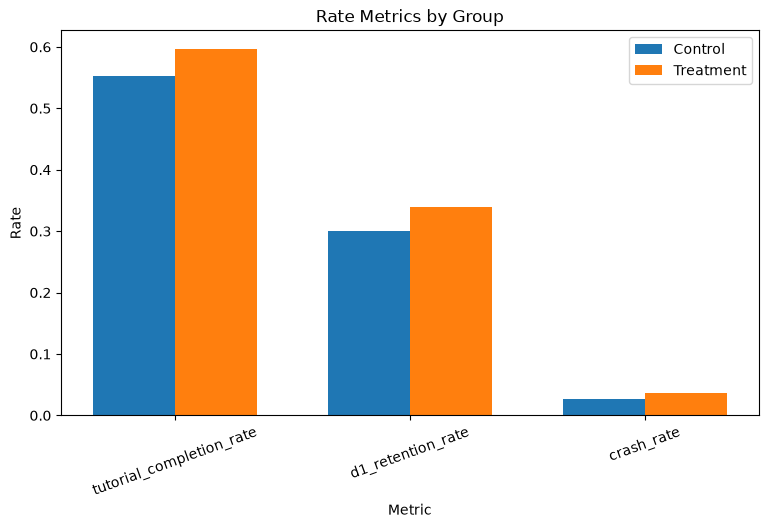

In [ ]:
# 绘制比例类指标
x = np.arange(len(rate_plot_df))    # len == 3 | x=[0,1,2]
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(
    x - width/2,
    rate_plot_df["control"],
    width,
    label="Control"
)

ax.bar(
    x + width/2,
    rate_plot_df["treatment"],
    width,
    label="Treatment"
)

ax.set_title("Rate Metrics by Group")
ax.set_xlabel("Metric")
ax.set_ylabel("Rate")
ax.set_xticks(x)
ax.set_xticklabels(rate_plot_df["metric"], rotation=20, ha="center")
ax.legend()

plt.show()

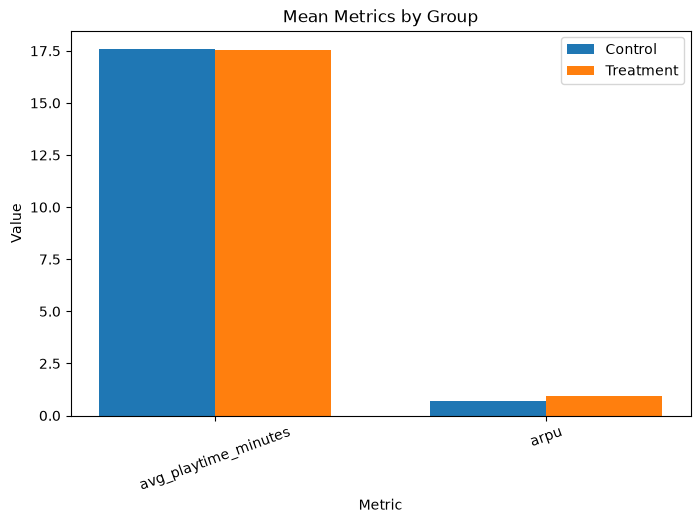

In [53]:
# 绘制均值类指标

mean_plot_df = metric_diff[
    metric_diff["metric"].isin(["avg_playtime_minutes","arpu"])
].copy()

x = np.arange(len(mean_plot_df))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    x - width/2,
    mean_plot_df["control"],
    width,
    label="Control"
)

ax.bar(
    x + width/2,
    mean_plot_df["treatment"],
    width,
    label="Treatment"
)

ax.set_title("Mean Metrics by Group")
ax.set_xlabel("Metric")
ax.set_ylabel("Value")
ax.set_xticks(x)
ax.set_xticklabels(mean_plot_df["metric"], rotation=20, ha="center")
ax.legend()

plt.show()

## Primary, Secondary, and Guardrail Metrics

### Primary Metric

Primary Metric 是实验最核心的成功判断标准。

例如：

$$
Primary\ Metric = D1\ Retention
$$

选择主指标时要满足：

- 与实验目标直接相关；
- 足够敏感；
- 不容易被短期噪音严重干扰；
- 能代表业务价值；
- 在实验开始前就确定。

### Secondary Metrics

Secondary Metrics 用来帮助解释主指标为什么变化。

例如：

- Tutorial Completion Rate；
- Average Playtime；
- Level Completion Rate；
- Session Count。

它们回答的是：

> 主指标变化是通过什么用户行为路径发生的？

### Guardrail Metrics

Guardrail Metrics 用来检查实验是否带来副作用。

例如：

- Crash Rate；
- Latency；
- Refund Rate；
- Complaint Rate；
- Uninstall Rate；
- Payment Conversion Rate。

它们回答的是：

> 新版本有没有伤害其他重要体验或业务指标？

# 01.04 Metric Denominator and Experimental Unit

A/B Test 中，一个非常容易被忽略的问题是：

> 实验单位和指标分母必须定义清楚。

常见的数据单位包括：

- User-level：用户级别；
- Session-level：会话级别；
- Event-level：事件级别；
- Order-level：订单级别；
- Pageview-level：页面浏览级别。

但是在大多数互联网产品实验中，随机分流通常发生在用户级别。

也就是说，一个用户被分到 Control Group 或 Treatment Group 后，这个用户后续产生的所有行为都属于同一个实验组。

因此，A/B Test 的统计分析通常应该回到 User-level。

否则会出现一个严重问题：

> 把同一个用户产生的多个事件当作多个独立样本，从而低估标准误，夸大显著性。

# 01.05 Random Variation in A/B Testing

即使一个实验的真实效果已经确定，每次实验得到的观测结果也可能不同。

原因是 A/B Test 不是观察全部用户，而是观察一批有限样本用户。

例如，假设真实转化率是：

- Control Group: 10%
- Treatment Group: 12%

真实差异是：

$$
p_T - p_C = 0.12 - 0.10 = 0.02
$$

也就是 2 percentage points。

但是在一次具体实验中，我们观察到的可能是：

- Control Group: 9.8%
- Treatment Group: 12.4%

也可能是：

- Control Group: 10.5%
- Treatment Group: 11.7%

甚至在样本较小时，可能出现 Treatment 组观测转化率低于 Control 组的情况。

这不是实验逻辑错误，而是抽样误差。

## 一个模拟例子

### 估计量随机波动的存在

In [ ]:
n_control = 1_000
n_treatment = 1_000

p_control = 0.10
p_treatment = 0.12

control_converted = rng.binomial(
    n=1,
    p=p_control,
    size=n_control
)

treatment_converted = rng.binomial(
    n=1,
    p=p_treatment,
    size=n_treatment
)

control_rate = control_converted.mean()
treatment_rate = treatment_converted.mean()

observed_lift = treatment_rate - control_rate
true_lift = p_treatment - p_control

print(f"Control Conversion Rate: {control_rate:.4f}")
print(f"Treatment Conversion Rate: {treatment_rate:.4f}")
print(f"Observed Lift: {observed_lift:.4f}")
print(f"True Lift: {true_lift:.4f}")

Control Conversion Rate: 0.0980
Treatment Conversion Rate: 0.1070
Observed Lift: 0.0090
True Lift: 0.0200


### 估计量随机波动的观测

In [ ]:
# 让我们做多次抽样观测，观察估计量的分布情况
def simulate_ab_test(
    n_control,
    n_treatment,
    p_control,
    p_treatment,
    rng
):
    # 模拟 Control 组转化结果
    control_converted = rng.binomial(
        n=1,
        p=p_control,
        size=n_control
    )

    # 模拟 Treatment 组转化结果
    treatment_converted = rng.binomial(
        n=1,
        p=p_treatment,
        size=n_treatment
    )

    # 计算两组观测转化率
    control_rate = control_converted.mean()
    treatment_rate = treatment_converted.mean()

    # 计算观测 lift
    observed_lift = treatment_rate - control_rate

    return observed_lift

In [ ]:
# 观察多次实验得到的潜在产出差异
n_simulations = 5_000

simulated_lifts = []

for _ in range(n_simulations):
    lift = simulate_ab_test(
        n_control=n_control,
        n_treatment=n_treatment,
        p_control=p_control,
        p_treatment=p_treatment,
        rng=rng
    )
    simulated_lifts.append(lift)

simulated_lifts = np.array(simulated_lifts)

simulated_lifts[:10]

array([ 0.013, -0.006,  0.027,  0.026,  0.007,  0.017,  0.044,  0.036,
        0.001,  0.012])

In [61]:
# 观察这些潜在产出差异的分布
simulation_summary = pd.DataFrame({
    "metric": [
        "True Lift",
        "Average Observed Lift",
        "Standard Deviation of Observed Lift",
        "Minimum Observed Lift",
        "Maximum Observed Lift"
    ],
    "value": [
        true_lift,
        simulated_lifts.mean(),
        simulated_lifts.std(ddof=1),
        simulated_lifts.min(),
        simulated_lifts.max()
    ]
})

simulation_summary

,metric,value
0,True Lift,0.020000
1,Average Observed Lift,0.019654
2,Standard Deviation of Observed Lift,0.013849
3,Minimum Observed Lift,-0.035000
4,Maximum Observed Lift,0.067000


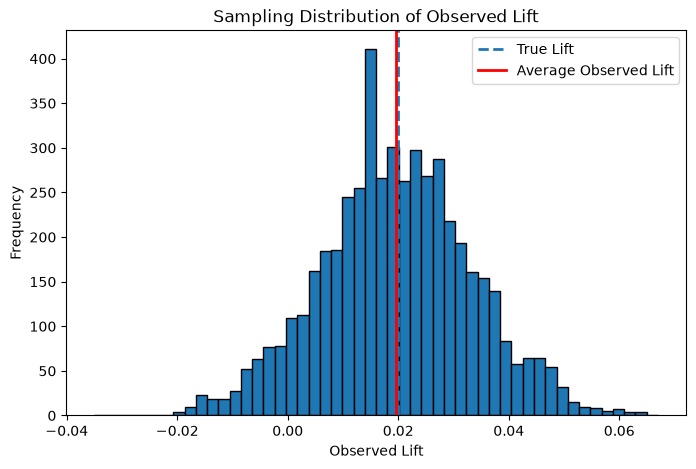

In [63]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    simulated_lifts,
    bins=50,
    edgecolor="black"
)

ax.axvline(
    true_lift,
    linestyle="--",
    linewidth=2,
    label="True Lift"
)

ax.axvline(
    simulated_lifts.mean(),
    linestyle="-",
    linewidth=2,
    color="red",
    label="Average Observed Lift"
)

ax.set_title("Sampling Distribution of Observed Lift")
ax.set_xlabel("Observed Lift")
ax.set_ylabel("Frequency")
ax.legend()

plt.show()

### 样本量对估计量波动的影响

In [ ]:
# 比较不同样本量情况下的Lift估计量波动
sample_sizes = [200, 500, 1_000, 5_000, 20_000]

sample_size_results = []

for n in sample_sizes:
    lifts = []

    for _ in range(n_simulations):
        lift = simulate_ab_test(
            n_control=n,
            n_treatment=n,
            p_control=p_control,
            p_treatment=p_treatment,
            rng=rng
        )
        lifts.append(lift)

    lifts = np.array(lifts)

    sample_size_results.append({
        "sample_size_per_group": n,
        "mean_observed_lift": lifts.mean(),
        "std_observed_lift": lifts.std(ddof=1),
        "min_observed_lift": lifts.min(),
        "max_observed_lift": lifts.max()
    })

sample_size_summary = pd.DataFrame(sample_size_results)

sample_size_summary

,sample_size_per_group,mean_observed_lift,std_observed_lift,min_observed_lift,max_observed_lift
0,200,0.019678,0.031406,-0.0950,0.1250
1,500,0.019552,0.020040,-0.0540,0.0920
2,1000,0.020054,0.013956,-0.0290,0.0720
3,5000,0.019953,0.006285,0.0002,0.0438
4,20000,0.020021,0.003107,0.0079,0.0327


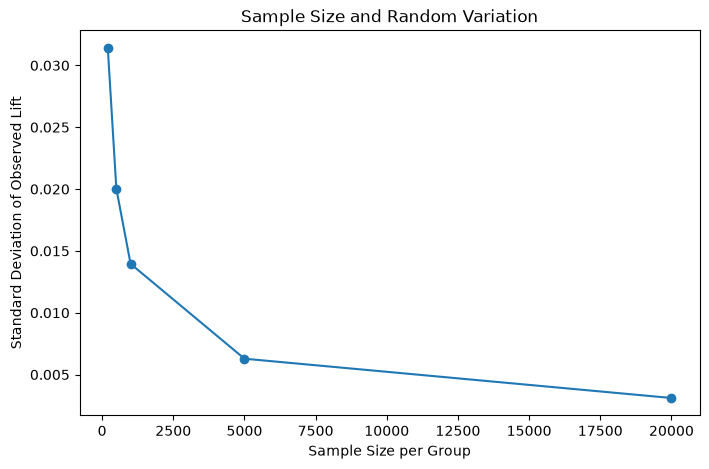

In [ ]:
# 不同样本量下Lift估计量的真实波动
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    sample_size_summary["sample_size_per_group"],
    sample_size_summary["std_observed_lift"],
    marker="o"
)

ax.set_title("Sample Size and Random Variation")
ax.set_xlabel("Sample Size per Group")
ax.set_ylabel("Standard Deviation of Observed Lift")

plt.show()

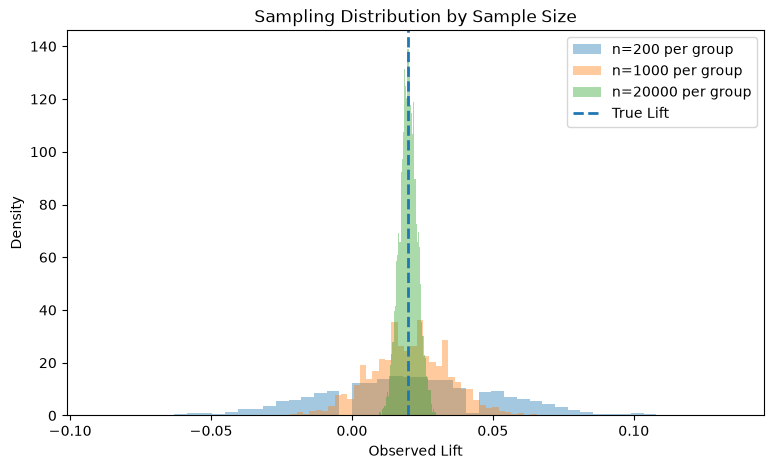

In [70]:
fig, ax = plt.subplots(figsize=(9, 5))

for n in [200, 1_000, 20_000]:
    lifts = []

    for _ in range(n_simulations):
        lift = simulate_ab_test(
            n_control=n,
            n_treatment=n,
            p_control=p_control,
            p_treatment=p_treatment,
            rng=rng
        )
        lifts.append(lift)

    ax.hist(
        lifts,
        bins=50,
        alpha=0.4,
        density=True,
        label=f"n={n} per group"
    )

ax.axvline(
    true_lift,
    linestyle="--",
    linewidth=2,
    label="True Lift"
)

ax.set_title("Sampling Distribution by Sample Size")
ax.set_xlabel("Observed Lift")
ax.set_ylabel("Density")
ax.legend()

plt.show()